# Random geometric network → zarr-vectors → Neuroglancer

End-to-end test for the zv-ngtools handler. Four stages:

1. Build a 10K-node random geometric network (nodes + edges) via scipy KDTree.
2. Visualize in matplotlib to verify the data looks sane.
3. Write a zarr-vectors graph store via `zarr_vectors.types.graphs.write_graph`.
4. Boot LocalNeuroglancer and load the store; the handler exposes the graph as two virtual annotation arrays (`nodes`, `edges`).

**Prerequisites:**
- `zv-ngtools` installed editable (`pip install -e .` from the repo root)
- `zarr-vectors` installed editable (`pip install -e .` from your local checkout)

Note: there's a polished, NetworkX/Plotly-based version of this notebook at [`examples/random_geometric_network.ipynb`](../../examples/random_geometric_network.ipynb). This one is the scipy-KDTree variant — same pipeline, different graph generator.

## Stage 1 — Build the random geometric network

In [1]:
import numpy as np
from scipy.spatial import cKDTree

N_NODES = 10_000
EXTENT = np.array([1000, 1000, 1000], dtype=np.float32)  # voxel units
SEED = 42

# Target ~30K edges. For a 3D random geometric graph, k-NN with k=6 gives roughly
# 30K undirected edges (N * k / 2 approximately, after dedup). Tune K_NEAREST if you
# want more or fewer.
K_NEAREST = 6

rng = np.random.default_rng(SEED)

# Nodes: uniform in the extent
nodes = rng.uniform(0, EXTENT, size=(N_NODES, 3)).astype(np.float32)

# Edges: each node connected to its K nearest neighbors, deduplicated
tree = cKDTree(nodes)
_, idx = tree.query(nodes, k=K_NEAREST + 1)  # +1 because self is nearest
edges_set = set()
for i, row in enumerate(idx):
    for j in row[1:]:  # skip self
        a, b = (i, j) if i < j else (j, i)
        edges_set.add((a, b))
edges = np.array(sorted(edges_set), dtype=np.int64)

print(f"Nodes: {len(nodes)}")
print(f"Edges: {len(edges)}")
print(f"Extent: {EXTENT}")
print(f"Node bounding box: min={nodes.min(axis=0)}, max={nodes.max(axis=0)}")

Nodes: 10000
Edges: 35847
Extent: [1000. 1000. 1000.]
Node bounding box: min=[0.04720983 0.10879628 0.01316856], max=[999.97705 999.9825  999.94727]


## Stage 2 — Visualize in matplotlib

Quick 3D sanity check before committing to the zarr-vectors conversion. Subsample both nodes and edges so the plot renders in a few seconds.

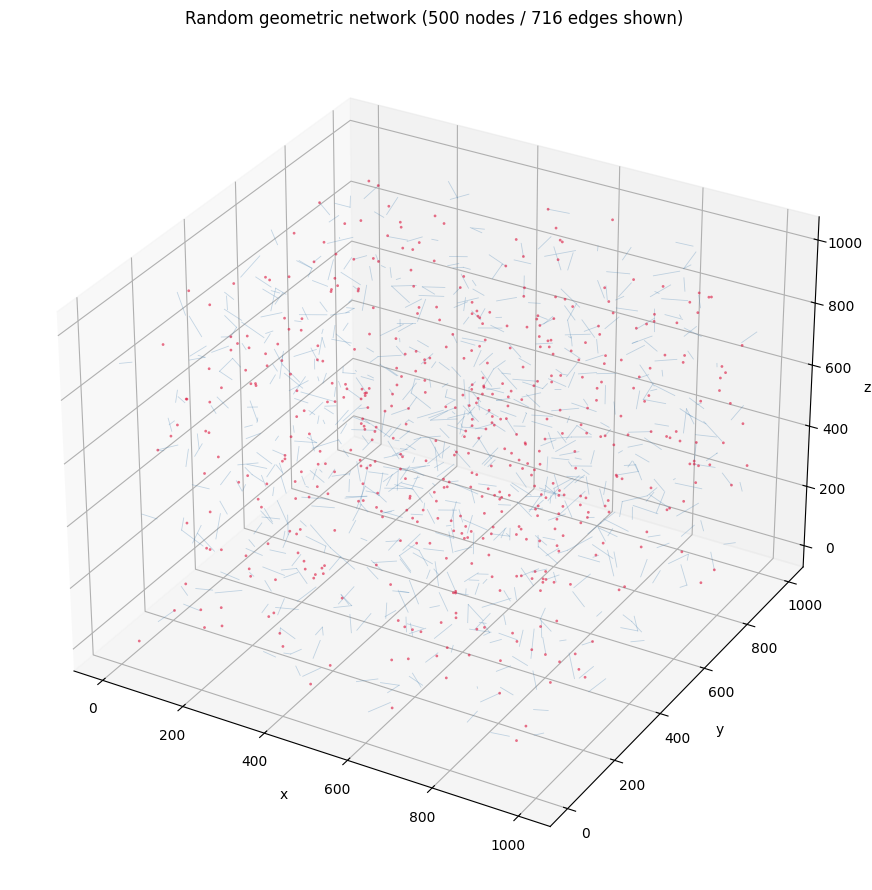

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (triggers 3D projection)

PLOT_NODE_FRAC = 0.05   # plot 5% of nodes (500)
PLOT_EDGE_FRAC = 0.02   # plot 2% of edges (~600)

n_plot_nodes = int(len(nodes) * PLOT_NODE_FRAC)
n_plot_edges = int(len(edges) * PLOT_EDGE_FRAC)
node_sample = rng.choice(len(nodes), size=n_plot_nodes, replace=False)
edge_sample = rng.choice(len(edges), size=n_plot_edges, replace=False)

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

# Edges as line segments
for e in edges[edge_sample]:
    p0, p1 = nodes[e[0]], nodes[e[1]]
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]],
            color='steelblue', alpha=0.3, linewidth=0.6)

# Nodes
ax.scatter(nodes[node_sample, 0], nodes[node_sample, 1], nodes[node_sample, 2],
           c='crimson', s=4, alpha=0.6, edgecolors='none')

ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title(f'Random geometric network ({n_plot_nodes} nodes / {n_plot_edges} edges shown)')
plt.tight_layout()
plt.show()

## Stage 3 — Write the zarr-vectors store

Graph data goes through `zarr_vectors.types.graphs.write_graph`, which produces a single store with geometry type `graph`. The zv-ngtools handler's adapter (`ngtools/local/zarrvectors._default_open_store`) wraps this graph store as two virtual annotation arrays — `nodes` (POINT) and `edges` (LINE/streamline) — exposing the per-array contract that the precomputed-encoding pipeline expects.

In [ ]:
import shutil
from pathlib import Path
from zarr_vectors.types.graphs import write_graph

STORE_PATH = Path.cwd() / "random_network.zarrvectors"
if STORE_PATH.exists():
    shutil.rmtree(STORE_PATH)

# Positions span [0, 1000]; chunk_shape=100 -> 10x10x10 chunk grid;
# bin_shape=25 -> 4x4x4 bins per chunk -> 40x40x40 fine-bin grid total.
result = write_graph(
    str(STORE_PATH),
    positions=nodes,
    edges=edges,
    chunk_shape=(100.0, 100.0, 100.0),
    bin_shape=(25.0, 25.0, 25.0),
    is_tree=False,
    dtype="float32",
)
print(f"Store written to: {STORE_PATH}")
print(result)

### Verify the store reads back through the handler contract

Before booting Neuroglancer, exercise the handler's expected methods directly. If these calls succeed, the store is consumable by zv-ngtools.

### Verify the store reads back through the handler contract

Open the store via the handler's adapter (the same path `viewer.load("zarrvectors://...")` uses internally) and exercise each per-array method that the precomputed encoder relies on. If these calls succeed, the store is consumable by zv-ngtools.

In [ ]:
# Open via the handler's adapter (wraps the real zarr_vectors graph store)
from ngtools.local.zarrvectors import _default_open_store

store_ro = _default_open_store("file", str(STORE_PATH))

for name in ["nodes", "edges"]:
    array = store_ro[name]
    print(f"\n--- {name} ---")
    print(f"  datatype:     {array.datatype}")
    print(f"  levels:       {array.levels}")
    print(f"  voxel_extent: {tuple(array.voxel_extent)}")
    print(f"  affine diag:  {np.asarray(array.affine).diagonal()}")
    for L in range(array.levels):
        bs = array.bin_size(L)
        gs = array.grid_shape(L)
        print(f"  L{L}: bin_size={bs} grid_shape={gs}")

    # Probe a populated bin at the finest level (adapter L0)
    array.limit_per_level()                 # populate all levels
    bins0 = array._bins_per_level[0]
    if bins0:
        ix, iy, iz = next(iter(bins0.keys()))
        segs = list(array.read_bin(0, ix, iy, iz))
        print(f"  read_bin(L0, {(ix, iy, iz)}): {len(segs)} segments")
        if segs:
            s = segs[0]
            print(f"    first: id={s.id}, prominence={s.prominence}, geom shape={np.asarray(s.geometry).shape}")

In [ ]:
# Exercise the handler's pure-logic functions directly (no HTTP needed).
# If these work, the HTTP handler will work too — the HTTP layer is just dispatch.
import struct
from ngtools.local.zarrvectors import (
    build_info, serve_spatial_chunk, serve_annotation_by_id,
)

edges_arr = store_ro["edges"]
info = build_info(edges_arr, "LINE")
print("edges info:")
print(f"  @type:           {info['@type']}")
print(f"  annotation_type: {info['annotation_type']}")
print(f"  spatial levels:  {len(info['spatial'])}")
for sp in info["spatial"]:
    print(f"    {sp['key']}: chunk={sp['chunk_size']} grid={sp['grid_shape']} limit={sp['limit']}")

# Pull a chunk from the coarsest level (spatial0); 0_0_0 is reliably populated.
body = serve_spatial_chunk(edges_arr, level=0, chunk_key="0_0_0", annotation_type="LINE")
(count,) = struct.unpack("<Q", body[:8])
print(f"\nspatial0/0_0_0: {count} segments, {len(body)} bytes")

# Round-trip one segment through by_id
by_id_body = serve_annotation_by_id(edges_arr, segment_id=1, annotation_type="LINE")
print(f"by_id/1: {len(by_id_body)} bytes")

In [ ]:
from ngtools.local.viewer import LocalNeuroglancer
import webbrowser

viewer = LocalNeuroglancer()
print(f"fileserver:   {viewer.get_fileserver_url()}")
print(f"neuroglancer: {viewer.get_viewer_url()}")

In [ ]:
# Load just the edges array first — the simplest path through the zv dispatch
zv_url = f"zarrvectors://{STORE_PATH}/@edges"
print(f"Loading: {zv_url}")
viewer.load(zv_url)

# Opens in default browser
webbrowser.open(viewer.get_viewer_url())

In [ ]:
# Load both arrays (fan-out) — should add a second layer
viewer.load(f"zarrvectors://{STORE_PATH}")

### Inspect cache state

After loading, both caches should show entries, and the refcount should be 1 per array.

In [ ]:
from ngtools.local.zarrvectors import (
    _info_cache, _geometry_cache, _by_id_index_cache, _array_refcount,
)

print(f"info cache entries:      {len(_info_cache)}")
print(f"geometry cache entries:  {len(_geometry_cache)}")
print(f"by_id cache entries:     {len(_by_id_index_cache)}")
print(f"array refcounts:         {dict(_array_refcount)}")
print(f"geometry cache bytes:    {_geometry_cache.total_bytes:,}")

### Force-reload after writing new data

If you modify the store externally (e.g., a pipeline run rewrites it) and `array.mtime()` is implemented, the handler auto-invalidates. Otherwise, call reload explicitly:

In [ ]:
from ngtools.local.zarrvectors import reload_zv_array, reload_all_zv_caches

# Flush one array's caches — handler rebuilds on next request
reload_zv_array(str(STORE_PATH), "edges")

# Or nuke everything:
# reload_all_zv_caches()

print(f"After reload: info cache={len(_info_cache)}, geometry cache={len(_geometry_cache)}")

## What to look for in Neuroglancer

If the dispatch wiring and handler work correctly, you should see:

- **Two layers** in the sidebar: `random_network/edges` and `random_network/nodes` (from the fan-out load), or just `random_network/edges` if you only did the single-array load.
- **Edges as line segments** filling the 1000×1000×1000 volume — they should look like a dense mesh of connections.
- **Nodes as individual points** scattered uniformly.
- **Smooth pan/zoom** — the handler returns only the spatial chunks intersecting the current viewport, so frame rate stays high.

### Likely first-run issues

1. **No layers appear, no error in console.** Check `viewer.state()` to see what was registered. If the layer is there but empty, open the browser dev console — you'll see HTTP requests going to `/zv/...` endpoints. 404s point to URL parsing issues in the handler; 500s point to the encoding/serving functions.
2. **Layers appear but are invisible / wrong scale.** Coordinate frame mismatch. The handler emits voxel coords and relies on the layer transform. Check the transform in the layer's 'source' tab — should be the identity affine you passed in. If it looks wrong, it's in `_register_zv_layer` in scene.py.
3. **Points render but edges don't.** The streamline/annotation_type=LINE path has one more encoder branch than POINT. Check the dev console for specific chunk request errors.
4. **`AttributeError` during load.** Handler is calling something the zarr-vectors array doesn't expose. Name of the missing method tells you what to add to zarr-vectors-py.